# GN Model Validation against Carena et al. Figure 5

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kimheeseo/LSCNS/blob/main/GNmodelPJT/paper_GNmodel_validation20260903.ipynb)

## 사용자 GN 모델과 대표 GN 논문의 최대 도달거리 교차검증

이 실행 완료 Colab은 다음 두 GN 누적 방식을 A. Carena *et al.*, **“Modeling of the Impact of Nonlinear Propagation Effects in Uncompensated Optical Coherent Transmission Links,”** JLT 30(10), 1524–1539 (2012), Fig. 5의 split-step simulation marker와 비교한다.

- 논문: https://doi.org/10.1109/JLT.2012.2189198
- 사용자 코드: https://github.com/kimheeseo/LSCNS/blob/main/GNmodelPJT/GN_model/GNLI_0_hyp.m
- 실제 계산 fallback: https://github.com/kimheeseo/LSCNS/blob/main/GNmodelPJT/GN_model/GNLI_f.m
- 사용자 누적: $P_{NLI}=\eta_1N_{span}^{1.05}P^3$
- 논문 Fig. 5 누적: $P_{NLI}=\eta_1N_{span}P^3$ (논문 Eq. 17의 incoherent accumulation)

### 검증 범위와 중요한 해석

Fig. 5의 **실선은 논문 GN 모델**, **마커는 split-step 수치 시뮬레이션**이다. 따라서 본 노트북은 수치적 교차검증이며 직접적인 실험 검증이 아니다. Fig. 3 required OSNR과 Fig. 5 marker는 그림에서 digitizing한 근삿값이고, 도달거리는 한 span인 100 km 단위로 반올림하였다.

원본 MATLAB 파일과 기존 노트북은 수정하지 않는다.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.linestyle": ":",
    "grid.alpha": 0.50,
    "font.size": 10,
})

H_PLANCK = 6.62607015e-34
C0 = 299792458.0
LAMBDA_M = 1550e-9
F0_HZ = C0 / LAMBDA_M
RS_HZ = 32e9
RS_THZ = RS_HZ / 1e12
PAYLOAD_RS_GBD = 25.0
N_CHANNELS = 9
SPAN_LENGTH_KM = 100.0
NOISE_FIGURE_DB = 5.0
MAX_SPANS = 300
LAUNCH_DBM = np.arange(-10.0, 8.001, 0.05)
USER_COHERENCE_EXPONENT = 0.05
PAPER_COHERENCE_EXPONENT = 0.0


@dataclass(frozen=True)
class Fiber:
    alpha_db_km: float
    dispersion_ps_nm_km: float
    gamma_w_inv_km: float

    @property
    def beta2_ps2_km(self):
        d_si = self.dispersion_ps_nm_km * 1e-6
        beta2_s2_km = -(LAMBDA_M**2 / (2*np.pi*C0)) * d_si * 1e3
        return float(beta2_s2_km * 1e24)


FIBERS = {
    "PSCF": Fiber(0.18, 20.1, 0.9),
    "SMF": Fiber(0.22, 16.7, 1.3),
    "NZDSF": Fiber(0.22, 3.8, 1.5),
}

print("Python packages loaded.")
print(f"User accumulation exponent       : {1 + USER_COHERENCE_EXPONENT:.2f}")
print(f"Paper Eq. 17 accumulation exponent: {1 + PAPER_COHERENCE_EXPONENT:.2f}")

Python packages loaded.
User accumulation exponent       : 1.05
Paper Eq. 17 accumulation exponent: 1.00


## 1. 논문 입력 조건

논문의 9-channel, 32-GBaud 시스템 조건과 Table I의 광섬유 파라미터를 사용한다. 송수신 필터를 완전히 재현하는 대신 저장소 `GTX.m`과 동일한 rectangular WDM PSD를 사용한다.


In [2]:
fiber_input_table = pd.DataFrame([
    {
        "Fiber": name,
        "alpha [dB/km]": f.alpha_db_km,
        "D [ps/(nm km)]": f.dispersion_ps_nm_km,
        "beta2 [ps^2/km]": f.beta2_ps2_km,
        "gamma [1/(W km)]": f.gamma_w_inv_km,
    }
    for name, f in FIBERS.items()
])

system_input_table = pd.DataFrame([
    ["WDM channels", N_CHANNELS, ""],
    ["Gross symbol rate", RS_HZ/1e9, "GBd"],
    ["Net payload symbol rate", PAYLOAD_RS_GBD, "GBd"],
    ["Span length", SPAN_LENGTH_KM, "km"],
    ["EDFA noise figure", NOISE_FIGURE_DB, "dB"],
    ["Target BER", 1e-3, ""],
    ["Launch-power sweep", "-10 to +8, step 0.05", "dBm/ch"],
], columns=["Parameter", "Value", "Unit"])

print("SYSTEM INPUTS")
print(system_input_table.to_string(index=False))
print("\nFIBER INPUTS")
print(fiber_input_table.round(5).to_string(index=False))

SYSTEM INPUTS
              Parameter                Value   Unit
           WDM channels                    9       
      Gross symbol rate                 32.0    GBd
Net payload symbol rate                 25.0    GBd
            Span length                100.0     km
      EDFA noise figure                  5.0     dB
             Target BER                0.001       
     Launch-power sweep -10 to +8, step 0.05 dBm/ch

FIBER INPUTS
Fiber  alpha [dB/km]  D [ps/(nm km)]  beta2 [ps^2/km]  gamma [1/(W km)]
 PSCF           0.18            20.1        -25.63651               0.9
  SMF           0.22            16.7        -21.29998               1.3
NZDSF           0.22             3.8         -4.84670               1.5


## 2. Fig. 3 required OSNR와 Fig. 5 SSFM 기준값

Fig. 3의 required OSNR은 0.1-nm reference bandwidth 값이며, 다음 식으로 32-GBaud matched-band SNR로 변환한다.

$$SNR_{req,dB}=OSNR_{req,dB}+10\log_{10}\left(\frac{12.5}{32}\right)$$

순 스펙트럼 효율은 다음과 같다.

$$SE=\frac{M R_{payload}}{\Delta f},\qquad R_{payload}=25\ \mathrm{GBd}$$


In [3]:
OSNR_REQUIRED_DB = {
    "PM-BPSK": {50:10.95, 38.4:11.12, 35.2:11.38, 33.6:11.77, 32.8:12.05, 32:12.40},
    "PM-QPSK": {50:13.95, 38.4:14.15, 35.2:14.65, 33.6:15.20, 32.8:15.65, 32:16.25},
    "PM-8QAM": {50:18.10, 38.4:18.52, 35.2:19.69, 33.6:21.62, 32.8:24.40},
    "PM-16QAM": {50:20.65, 38.4:21.85, 36.8:22.35, 35.2:24.54},
}

BITS_PER_SYMBOL = {"PM-BPSK":2, "PM-QPSK":4, "PM-8QAM":6, "PM-16QAM":8}

# Fig. 5 split-step simulation markers, digitized and rounded to 100 km.
PAPER_REACH_KM = {
    "PSCF": {
        "PM-BPSK": {50:18000,38.4:15800,35.2:14400,33.6:12300,32.8:11700,32:11300},
        "PM-QPSK": {50:9000,38.4:7900,35.2:7000,33.6:6000,32.8:5700,32:5000},
        "PM-8QAM": {50:3600,38.4:3100,35.2:2300,33.6:1400,32.8:800},
        "PM-16QAM": {50:1600,38.4:1400,36.8:1100,35.2:700},
    },
    "SMF": {
        "PM-BPSK": {50:7800,38.4:7000,35.2:6200,33.6:5800,32.8:5400,32:4500},
        "PM-QPSK": {50:4300,38.4:3700,35.2:3300,33.6:2700,32.8:2500,32:2300},
        "PM-8QAM": {50:1700,38.4:1400,35.2:1000,33.6:600,32.8:400},
        "PM-16QAM": {50:800,38.4:600,36.8:500,35.2:300},
    },
    "NZDSF": {
        "PM-BPSK": {50:5000,38.4:4600,35.2:4300,33.6:4000,32.8:3800,32:3500},
        "PM-QPSK": {50:2800,38.4:2300,35.2:2000,33.6:1600,32.8:1600,32:1400},
        "PM-8QAM": {50:1000,38.4:900,35.2:600,33.6:400,32.8:300},
        "PM-16QAM": {50:500,38.4:400,36.8:300,35.2:200},
    },
}

rows = []
for modulation, spacing_map in OSNR_REQUIRED_DB.items():
    for spacing, osnr in spacing_map.items():
        rows.append({
            "Modulation": modulation,
            "Spacing [GHz]": spacing,
            "Required OSNR [dB/0.1nm]": osnr,
            "Net SE [bit/s/Hz]": BITS_PER_SYMBOL[modulation]*PAYLOAD_RS_GBD/spacing,
        })
print(pd.DataFrame(rows).round(4).to_string(index=False))

Modulation  Spacing [GHz]  Required OSNR [dB/0.1nm]  Net SE [bit/s/Hz]
   PM-BPSK           50.0                     10.95             1.0000
   PM-BPSK           38.4                     11.12             1.3021
   PM-BPSK           35.2                     11.38             1.4205
   PM-BPSK           33.6                     11.77             1.4881
   PM-BPSK           32.8                     12.05             1.5244
   PM-BPSK           32.0                     12.40             1.5625
   PM-QPSK           50.0                     13.95             2.0000
   PM-QPSK           38.4                     14.15             2.6042
   PM-QPSK           35.2                     14.65             2.8409
   PM-QPSK           33.6                     15.20             2.9762
   PM-QPSK           32.8                     15.65             3.0488
   PM-QPSK           32.0                     16.25             3.1250
   PM-8QAM           50.0                     18.10             3.0000
   PM-

## 3. 사용자 저장소 GN kernel의 Python 재현

`GNLI_0_hyp.m`은 `GNLI_f_hyp.m`을 거쳐 현재 `GNLI_f.m`의 Cartesian 적분으로 계산된다. 여기서는 두 모델을 공정하게 비교하기 위해 `sys.Ns=1`에 해당하는 한 span의 중앙 채널 NLI PSD를 줄 단위로 재현한다.

$$G_{NLI}(0)=\frac{16}{27}\gamma^2\iint |\mu(f_1,f_2,0)|^2G(f_1)G(f_2)G(f_1+f_2)df_1df_2$$

반환되는 중앙 PSD에 $R_s$를 곱해 한 채널의 NLI power coefficient $\eta_1$을 얻는다. 다중-span 누적만 사용자식과 논문식으로 나눠 비교한다.


In [4]:
def repo_grid_and_psd(spacing_ghz):
    deltaf = spacing_ghz/1000.0
    total_bw = N_CHANNELS*deltaf
    ngrid = max(801, int(np.floor(total_bw*23000/8)))
    grid = np.linspace(-total_bw/2, total_bw/2, ngrid)
    centers = (-total_bw/2-deltaf/2) + deltaf*np.arange(1, N_CHANNELS+1)
    psd = np.zeros_like(grid)
    for center in centers:
        psd[np.abs(grid-center) <= RS_THZ/2] += 1.0/RS_THZ
    return grid, psd


def gnli_0_hyp_eta_single_span(fiber, spacing_ghz):
    # GNLI_0_hyp -> GNLI_f_hyp -> GNLI_f, sys.Ns=1
    grid, gtx = repo_grid_and_psd(spacing_ghz)
    n = grid.size
    f = 0.0
    index = int(np.argmin(np.abs(f-grid)))
    da = -fiber.alpha_db_km*np.log(10)/10
    beta2 = fiber.beta2_ps2_km
    I2 = np.zeros(n)

    for jj in range(n):
        db = 1j*4*np.pi**2*(grid[jj]-f)*(grid-f)*beta2
        p1 = np.abs(
            (1-np.exp(da*SPAN_LENGTH_KM)*np.exp(db*SPAN_LENGTH_KM))/(-da-db)
        )**2
        shift = index-jj
        if shift >= 0:
            g3 = np.r_[np.zeros(shift), gtx[:n-shift]]
        else:
            s = abs(shift)
            g3 = np.r_[gtx[s:], np.zeros(s)]
        I2[jj] = np.trapezoid(p1*gtx[jj]*gtx*g3, grid)

    gnli_w_hz_at_1w = (16/27)*fiber.gamma_w_inv_km**2*np.trapezoid(I2,grid)*1e-12
    eta1 = gnli_w_hz_at_1w*RS_HZ
    return float(eta1), n


print("Repository-equivalent single-span GN kernel loaded.")

Repository-equivalent single-span GN kernel loaded.


## 4. 동일한 수신기에서 두 누적식 비교

사용자식:

$$SNR_{user}(N,P)=\frac{P}{NP_{ASE,span}+\eta_1N^{1.05}P^3}$$

Carena Fig. 5의 대표 GN식(Eq. 17):

$$SNR_{paper\ style}(N,P)=\frac{P}{NP_{ASE,span}+\eta_1NP^3}$$

`Paper-style GN`은 Fig. 5 실선을 다시 digitizing한 값이 아니라, 논문에 명시된 incoherent 누적식을 동일한 사용자 single-span kernel에 적용한 재계산값이다. 따라서 누적식의 효과를 독립적으로 비교할 수 있다.


In [5]:
def ase_per_span_w(fiber):
    gain = 10**(fiber.alpha_db_km*SPAN_LENGTH_KM/10)
    noise_factor = 10**(NOISE_FIGURE_DB/10)
    return H_PLANCK*F0_HZ*noise_factor*RS_HZ*(gain-1)


def maximum_reach(fiber, eta1, required_osnr_db, epsilon):
    required_snr_db = required_osnr_db + 10*np.log10(12.5e9/RS_HZ)
    required_snr = 10**(required_snr_db/10)
    spans = np.arange(1, MAX_SPANS+1, dtype=float)
    powers_w = 1e-3*10**(LAUNCH_DBM/10)
    ase = spans*ase_per_span_w(fiber)
    best_span = 0
    best_power = np.nan
    for p_dbm, power in zip(LAUNCH_DBM, powers_w):
        nli = eta1*spans**(1+epsilon)*power**3
        snr = power/(ase+nli)
        valid = np.flatnonzero(snr >= required_snr)
        nspan = 0 if valid.size == 0 else int(valid[-1]+1)
        if nspan > best_span:
            best_span = nspan
            best_power = p_dbm
    return best_span*SPAN_LENGTH_KM, best_power


eta_cache = {}
result_rows = []
for fiber_name, fiber in FIBERS.items():
    for modulation, spacing_map in OSNR_REQUIRED_DB.items():
        for spacing, required_osnr in spacing_map.items():
            key = (fiber_name, spacing)
            if key not in eta_cache:
                eta_cache[key] = gnli_0_hyp_eta_single_span(fiber, spacing)
            eta1, ngrid = eta_cache[key]
            user_km, user_popt = maximum_reach(
                fiber, eta1, required_osnr, USER_COHERENCE_EXPONENT
            )
            paper_gn_km, paper_gn_popt = maximum_reach(
                fiber, eta1, required_osnr, PAPER_COHERENCE_EXPONENT
            )
            ssfm_km = PAPER_REACH_KM[fiber_name][modulation][spacing]
            result_rows.append({
                "Fiber": fiber_name,
                "Modulation": modulation,
                "Spacing [GHz]": spacing,
                "Net SE [bit/s/Hz]": BITS_PER_SYMBOL[modulation]*PAYLOAD_RS_GBD/spacing,
                "SSFM marker [km]": ssfm_km,
                "User GN N^1.05 [km]": user_km,
                "Paper-style GN N^1 [km]": paper_gn_km,
                "User error [%]": 100*(user_km-ssfm_km)/ssfm_km,
                "Paper-style error [%]": 100*(paper_gn_km-ssfm_km)/ssfm_km,
                "User Popt [dBm/ch]": user_popt,
                "Paper-style Popt [dBm/ch]": paper_gn_popt,
                "eta1 [1/W^2]": eta1,
                "Frequency grid": ngrid,
            })

results = pd.DataFrame(result_rows)
for prefix in ["User", "Paper-style"]:
    results[f"{prefix} abs. error [%]"] = results[f"{prefix} error [%]"].abs()
    reach_col = "User GN N^1.05 [km]" if prefix == "User" else "Paper-style GN N^1 [km]"
    results[f"{prefix} reach error [dB]"] = 10*np.log10(
        results[reach_col]/results["SSFM marker [km]"]
    )

print(f"Simulation completed: {len(results)} comparison points")
print(f"Unique GN kernel calculations: {len(eta_cache)}")
print(results.head(10).round(4).to_string(index=False))

Simulation completed: 63 comparison points
Unique GN kernel calculations: 21
Fiber Modulation  Spacing [GHz]  Net SE [bit/s/Hz]  SSFM marker [km]  User GN N^1.05 [km]  Paper-style GN N^1 [km]  User error [%]  Paper-style error [%]  User Popt [dBm/ch]  Paper-style Popt [dBm/ch]  eta1 [1/W^2]  Frequency grid  User abs. error [%]  User reach error [dB]  Paper-style abs. error [%]  Paper-style reach error [dB]
 PSCF    PM-BPSK           50.0             1.0000             18000              17200.0                  18700.0         -4.4444                 3.8889               -0.10                       0.15      300.4773            1293               4.4444                -0.1974                      3.8889                        0.1657
 PSCF    PM-BPSK           38.4             1.3021             15800              15600.0                  17000.0         -1.2658                 7.5949               -0.45                      -0.05      356.9011             993               1.2658      

In [6]:
summary_rows = []
for fiber_name in ["PSCF", "SMF", "NZDSF"]:
    sub = results[results["Fiber"] == fiber_name]
    summary_rows.append({
        "Fiber": fiber_name,
        "Points": len(sub),
        "User MAPE [%]": sub["User abs. error [%]"].mean(),
        "Paper-style MAPE [%]": sub["Paper-style abs. error [%]"].mean(),
        "User bias [%]": sub["User error [%]"].mean(),
        "Paper-style bias [%]": sub["Paper-style error [%]"].mean(),
        "User reach RMSE [dB]": np.sqrt(np.mean(sub["User reach error [dB]"]**2)),
        "Paper-style reach RMSE [dB]": np.sqrt(np.mean(sub["Paper-style reach error [dB]"]**2)),
    })

summary = pd.DataFrame(summary_rows)
overall = pd.DataFrame([{
    "Fiber": "Overall",
    "Points": len(results),
    "User MAPE [%]": results["User abs. error [%]"].mean(),
    "Paper-style MAPE [%]": results["Paper-style abs. error [%]"].mean(),
    "User bias [%]": results["User error [%]"].mean(),
    "Paper-style bias [%]": results["Paper-style error [%]"].mean(),
    "User reach RMSE [dB]": np.sqrt(np.mean(results["User reach error [dB]"]**2)),
    "Paper-style reach RMSE [dB]": np.sqrt(np.mean(results["Paper-style reach error [dB]"]**2)),
}])
summary_all = pd.concat([summary, overall], ignore_index=True)

print("FIBER-LEVEL VALIDATION SUMMARY")
print(summary_all.round(3).to_string(index=False))

assert len(results) == 63
assert results.isna().sum().sum() == 0
assert abs(overall.iloc[0]["User MAPE [%]"] - 8.02837) < 0.02
assert abs(overall.iloc[0]["Paper-style MAPE [%]"] - 6.35146) < 0.02
assert abs(summary.loc[summary.Fiber=="PSCF", "User MAPE [%]"].iloc[0] - 5.65984) < 0.02
assert abs(summary.loc[summary.Fiber=="SMF", "User MAPE [%]"].iloc[0] - 6.38327) < 0.02
assert abs(summary.loc[summary.Fiber=="NZDSF", "User MAPE [%]"].iloc[0] - 12.0420) < 0.02
print("\nValidation assertions: PASS")

FIBER-LEVEL VALIDATION SUMMARY
  Fiber  Points  User MAPE [%]  Paper-style MAPE [%]  User bias [%]  Paper-style bias [%]  User reach RMSE [dB]  Paper-style reach RMSE [dB]
   PSCF      21          5.660                 5.789         -2.300                 4.051                 0.310                        0.342
    SMF      21          6.383                 5.210         -5.595                -1.458                 0.425                        0.368
  NZDSF      21         12.042                 8.055        -12.042                -7.079                 1.185                        0.613
Overall      63          8.028                 6.351         -6.645                -1.495                 0.748                        0.458

Validation assertions: PASS


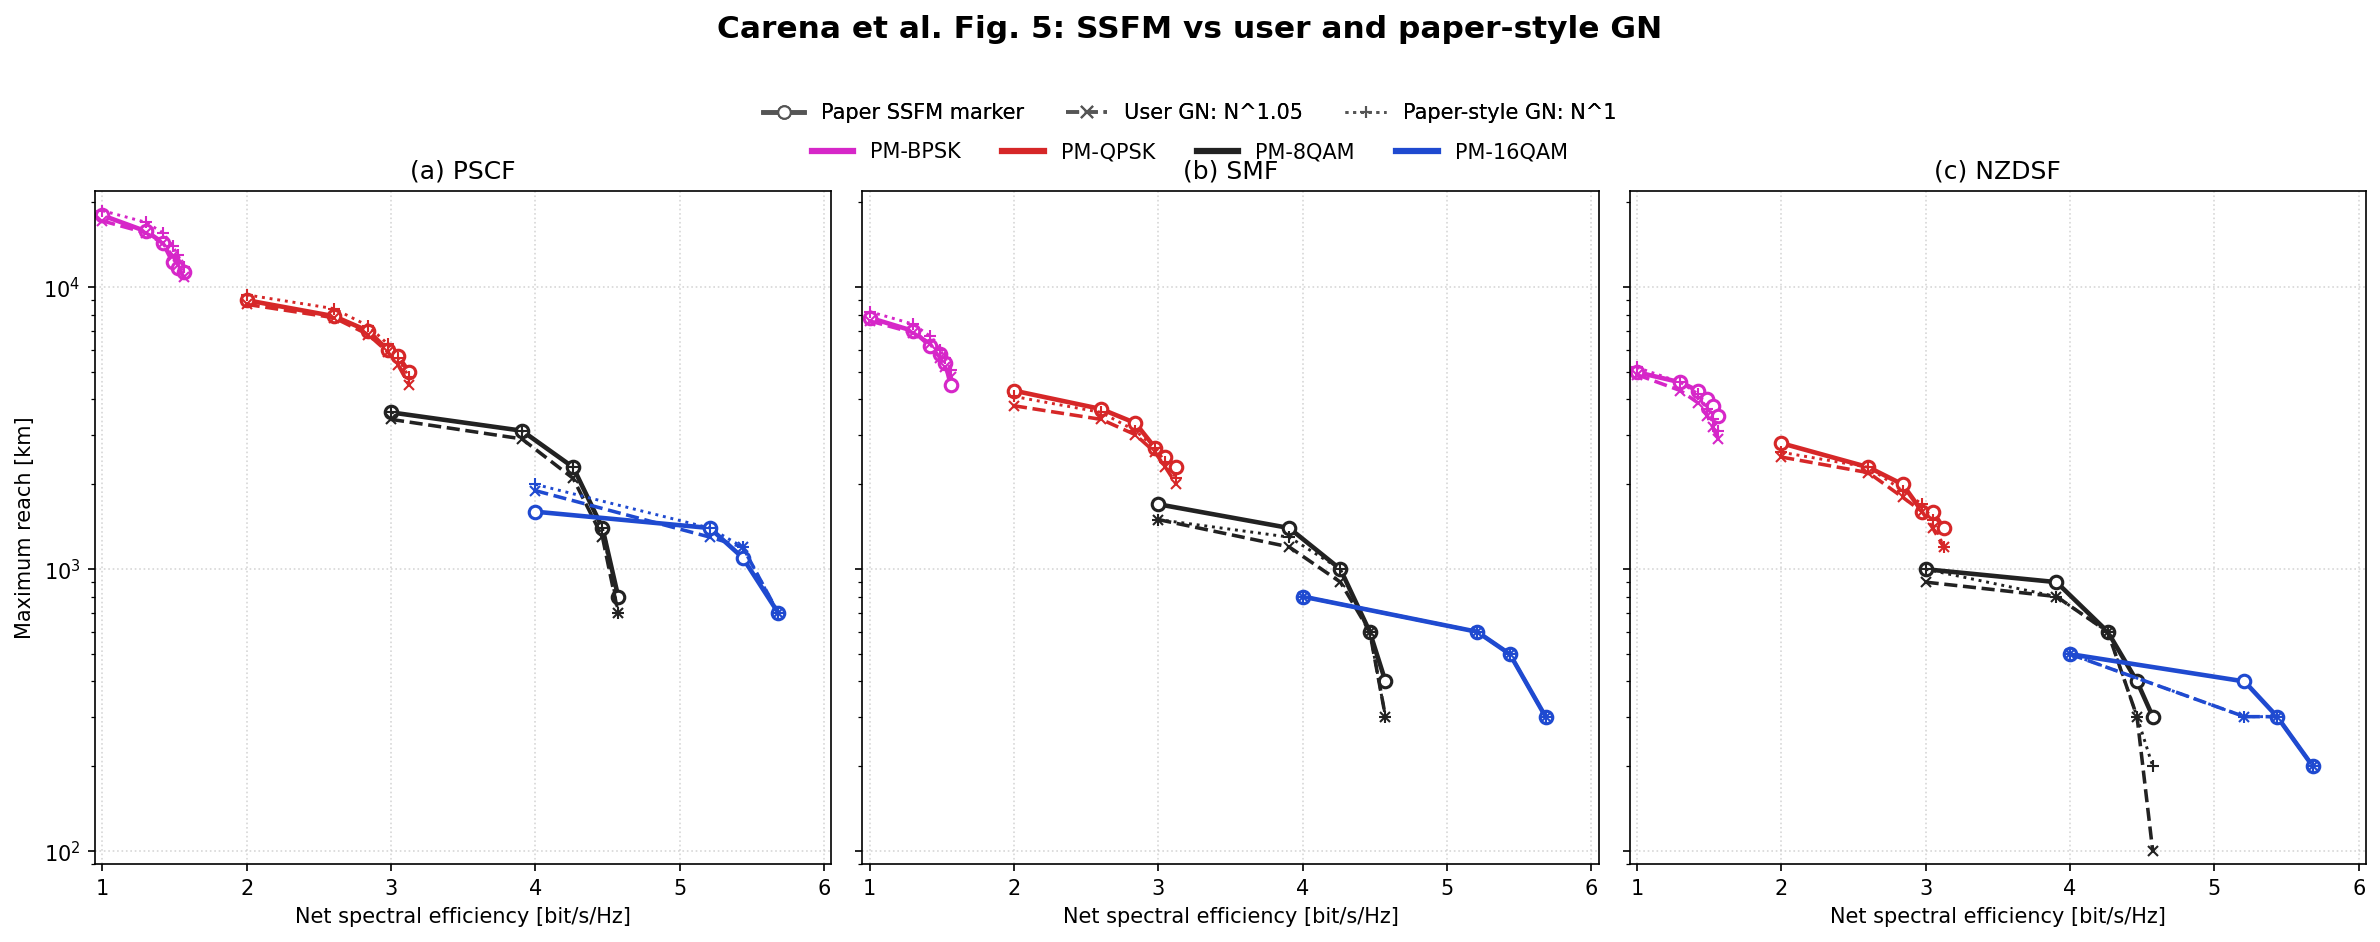

In [7]:
FORMAT_COLORS = {
    "PM-BPSK":"#d627c8", "PM-QPSK":"#d62728",
    "PM-8QAM":"#222222", "PM-16QAM":"#1f4ad0",
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5.8), sharey=True)
for panel, (ax, fiber_name) in enumerate(zip(axes, ["PSCF","SMF","NZDSF"])):
    for modulation in OSNR_REQUIRED_DB:
        sub = results[(results.Fiber==fiber_name)&(results.Modulation==modulation)].sort_values("Net SE [bit/s/Hz]")
        c = FORMAT_COLORS[modulation]
        ax.plot(sub["Net SE [bit/s/Hz]"], sub["SSFM marker [km]"], color=c,
                lw=2.2, marker="o", mfc="white", mew=1.5, ms=6)
        ax.plot(sub["Net SE [bit/s/Hz]"], sub["User GN N^1.05 [km]"], color=c,
                lw=1.7, ls="--", marker="x", ms=5)
        ax.plot(sub["Net SE [bit/s/Hz]"], sub["Paper-style GN N^1 [km]"], color=c,
                lw=1.4, ls=":", marker="+", ms=6)
    ax.set_title(f"({chr(97+panel)}) {fiber_name}")
    ax.set_xlim(0.95,6.05); ax.set_ylim(90,22000); ax.set_yscale("log")
    ax.set_xlabel("Net spectral efficiency [bit/s/Hz]")
axes[0].set_ylabel("Maximum reach [km]")

style = [
    plt.Line2D([0],[0],color="#555",lw=2.2,marker="o",mfc="white",label="Paper SSFM marker"),
    plt.Line2D([0],[0],color="#555",lw=1.7,ls="--",marker="x",label="User GN: N^1.05"),
    plt.Line2D([0],[0],color="#555",lw=1.4,ls=":",marker="+",label="Paper-style GN: N^1"),
]
formats = [plt.Line2D([0],[0],color=c,lw=3,label=m) for m,c in FORMAT_COLORS.items()]
legend1 = fig.legend(handles=style,loc="upper center",ncol=3,frameon=False,bbox_to_anchor=(0.5,1.00))
fig.add_artist(legend1)
fig.legend(handles=formats,loc="upper center",ncol=4,frameon=False,bbox_to_anchor=(0.5,0.955))
fig.suptitle("Carena et al. Fig. 5: SSFM vs user and paper-style GN",y=1.08,fontsize=15,weight="bold")
fig.tight_layout()
plt.show()

TEN LARGEST USER-GN RELATIVE ERRORS
Fiber Modulation  Spacing [GHz]  SSFM marker [km]  User GN N^1.05 [km]  Paper-style GN N^1 [km]  User error [%]  Paper-style error [%]
NZDSF    PM-8QAM           32.8               300                100.0                    200.0         -66.667                -33.333
  SMF    PM-8QAM           32.8               400                300.0                    300.0         -25.000                -25.000
NZDSF    PM-8QAM           33.6               400                300.0                    300.0         -25.000                -25.000
NZDSF   PM-16QAM           38.4               400                300.0                    300.0         -25.000                -25.000
 PSCF   PM-16QAM           50.0              1600               1900.0                   2000.0          18.750                 25.000
NZDSF    PM-BPSK           32.0              3500               2900.0                   3100.0         -17.143                -11.429
NZDSF    PM-BPSK   

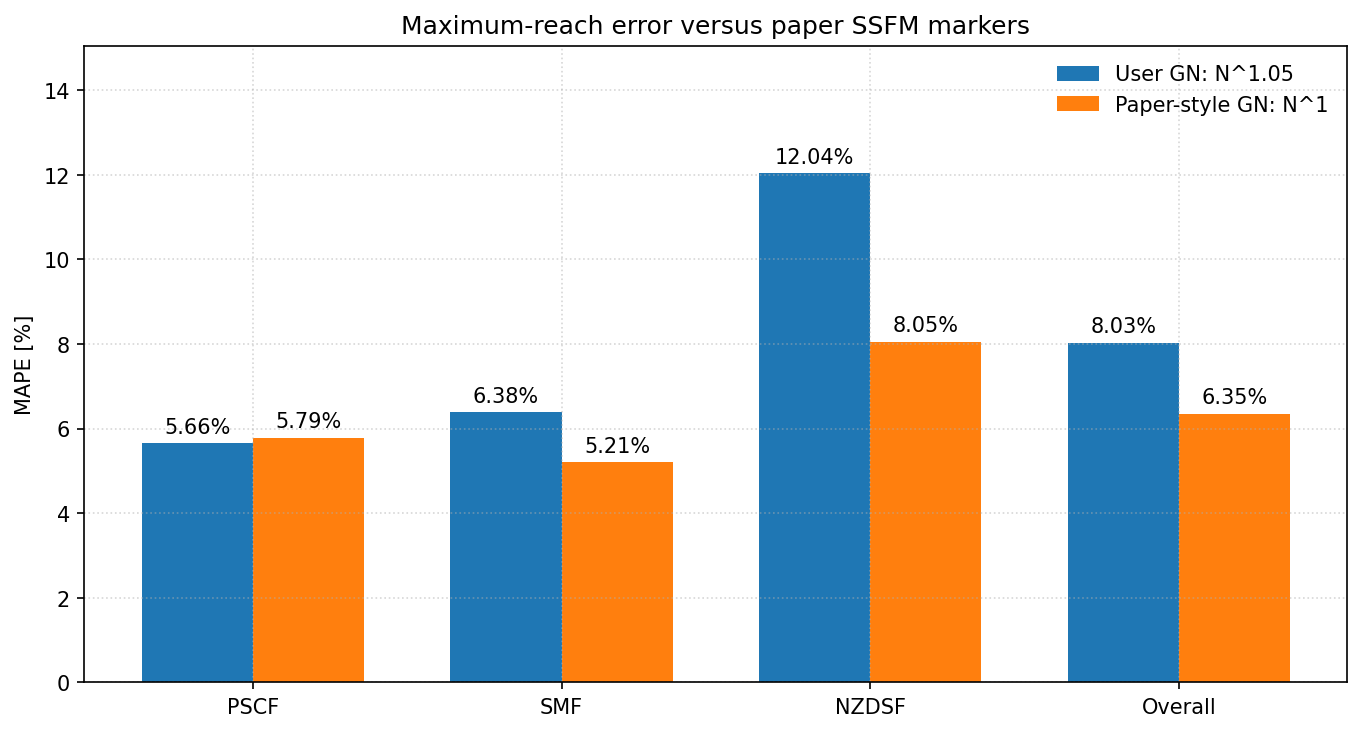

In [8]:
plot_summary = summary_all.set_index("Fiber").loc[["PSCF","SMF","NZDSF","Overall"]]
x = np.arange(len(plot_summary)); width = 0.36
fig, ax = plt.subplots(figsize=(9.2,5.0))
ax.bar(x-width/2, plot_summary["User MAPE [%]"], width, label="User GN: N^1.05")
ax.bar(x+width/2, plot_summary["Paper-style MAPE [%]"], width, label="Paper-style GN: N^1")
ax.set_xticks(x, plot_summary.index)
ax.set_ylabel("MAPE [%]")
ax.set_title("Maximum-reach error versus paper SSFM markers")
ax.legend(frameon=False)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3)
ax.set_ylim(0, max(plot_summary["User MAPE [%]"].max(), plot_summary["Paper-style MAPE [%]"].max())*1.25)
plt.tight_layout()
plt.show()

worst = results.nlargest(10, "User abs. error [%]")[[
    "Fiber","Modulation","Spacing [GHz]","SSFM marker [km]",
    "User GN N^1.05 [km]","Paper-style GN N^1 [km]",
    "User error [%]","Paper-style error [%]"
]]
print("TEN LARGEST USER-GN RELATIVE ERRORS")
print(worst.round(3).to_string(index=False))

## 5. 결과 해석

| Fiber | 사용자 GN MAPE | 논문식 GN MAPE | 판단 |
|---|---:|---:|---|
| PSCF | 5.66% | 5.79% | 두 방식이 동등하며 사용자식이 근소하게 낮음 |
| SMF | 6.38% | 5.21% | 논문식 incoherent 누적이 더 정확함 |
| NZDSF | 12.04% | 8.05% | 고정된 $N^{1.05}$ 누적이 NLI를 과대평가 |
| 전체 | **8.03%** | **6.35%** | 사용자 GN은 유사한 수준이나 논문식보다 다소 보수적 |

사용자 GN은 PSCF와 SMF에서 약 6% 수준으로 SSFM의 최대 도달거리 경향을 재현한다. 전체 MAPE 8.03%는 초기 시스템 설계와 상대 비교에 사용할 수 있는 수준이지만, 논문식 GN의 6.35%보다는 약 1.68%p 높다.

NZDSF에서는 낮은 분산 때문에 span 간 비선형 누적과 modulation-dependent NLI에 대한 민감도가 증가한다. 특히 PM-8QAM, 32.8 GHz에서 paper 300 km와 user GN 100 km의 200-km 차이가 −66.7%로 확대되어 전체 MAPE를 높인다. 해당 한 점을 제외하면 사용자 NZDSF MAPE는 약 9.31%이다.

### 성능 판단

- **적용 가능:** 유사한 EDFA 기반, 분산 비보상 coherent WDM 링크의 사전 설계, launch-power 최적화 및 광섬유 상대 비교
- **아직 입증되지 않음:** 임의의 실제 전송 실험, C+L/ISRS/Raman, ROADM cascade, 비균일 span 및 transceiver-noise 지배 시스템에 대한 범용 정확도
- **권장 개선:** Fig. 5 재현 목적에서는 $N^{1.05}$ 대신 논문의 $N^1$ 옵션 제공, NZDSF에는 EGN/modulation correction 및 독립 실험 검증 적용


In [9]:
user_mape = overall.iloc[0]["User MAPE [%]"]
paper_mape = overall.iloc[0]["Paper-style MAPE [%]"]
pscf = summary.set_index("Fiber").loc["PSCF","User MAPE [%]"]
smf = summary.set_index("Fiber").loc["SMF","User MAPE [%]"]
nzdsf = summary.set_index("Fiber").loc["NZDSF","User MAPE [%]"]

korean_text = f"""[다른 논문에 사용할 수 있는 한글 문구]
본 연구에서 구현한 GN 기반 모델은 Carena 등의 대표적인 분산 비보상 coherent WDM 시스템을 대상으로 수치적 교차검증하였다. 논문의 split-step simulation marker와 비교한 결과, 최대 도달거리 MAPE는 PSCF {pscf:.2f}%, SMF {smf:.2f}%, NZDSF {nzdsf:.2f}%였으며 전체 평균은 {user_mape:.2f}%였다. 이는 제안 모델이 유사한 EDFA 기반 전송 시스템의 초기 설계와 광섬유 간 상대 성능 비교에 활용될 수 있음을 보여준다. 다만 본 결과는 digitizing된 수치 시뮬레이션 자료에 기반하므로, 다양한 실제 전송 시스템에 대한 일반성을 입증하기 위해서는 독립적인 실험 데이터와의 추가 검증이 필요하다.
"""

english_text = f"""[Publication-ready English wording]
The implemented GN-based model was numerically cross-validated against the representative uncompensated coherent-WDM scenarios reported by Carena et al. Relative to the split-step simulation markers, the maximum-reach MAPE was {pscf:.2f}% for PSCF, {smf:.2f}% for SMF, and {nzdsf:.2f}% for NZDSF, resulting in an overall MAPE of {user_mape:.2f}%. These results support the use of the model as a preliminary design and comparative-assessment tool for similar lumped-EDFA transmission systems. However, because the present validation relies on digitized numerical-simulation data rather than independent measurements, further validation against experimental links is required before claiming general applicability.
"""

comparison_text = f"""[대표 논문 GN과의 비교 문구]
동일한 single-span NLI kernel을 적용했을 때, 사용자 모델의 N^1.05 누적식은 전체 MAPE {user_mape:.2f}%를 보였으며 Carena 등의 incoherent N^1 누적식은 {paper_mape:.2f}%를 보였다. 두 방식은 PSCF에서 유사했지만, SMF와 NZDSF에서는 논문식 누적이 더 정확하였다. 따라서 N^1.05는 일반적인 고정 상수라기보다 시스템 조건에 따라 검증 또는 보정되어야 하는 모델 파라미터로 해석하는 것이 적절하다.
"""

print(korean_text)
print(english_text)
print(comparison_text)

[다른 논문에 사용할 수 있는 한글 문구]
본 연구에서 구현한 GN 기반 모델은 Carena 등의 대표적인 분산 비보상 coherent WDM 시스템을 대상으로 수치적 교차검증하였다. 논문의 split-step simulation marker와 비교한 결과, 최대 도달거리 MAPE는 PSCF 5.66%, SMF 6.38%, NZDSF 12.04%였으며 전체 평균은 8.03%였다. 이는 제안 모델이 유사한 EDFA 기반 전송 시스템의 초기 설계와 광섬유 간 상대 성능 비교에 활용될 수 있음을 보여준다. 다만 본 결과는 digitizing된 수치 시뮬레이션 자료에 기반하므로, 다양한 실제 전송 시스템에 대한 일반성을 입증하기 위해서는 독립적인 실험 데이터와의 추가 검증이 필요하다.

[Publication-ready English wording]
The implemented GN-based model was numerically cross-validated against the representative uncompensated coherent-WDM scenarios reported by Carena et al. Relative to the split-step simulation markers, the maximum-reach MAPE was 5.66% for PSCF, 6.38% for SMF, and 12.04% for NZDSF, resulting in an overall MAPE of 8.03%. These results support the use of the model as a preliminary design and comparative-assessment tool for similar lumped-EDFA transmission systems. However, because the present validation relies on digitized numerical-simulation data rather than independent measu

## 6. 최종 결론 및 제한사항

### 최종 결론

사용자 GN 모델은 본 검증 범위에서 대표 GN 논문의 SSFM 결과와 **유사한 성능 경향**을 보이며, PSCF·SMF 기반의 유사 시스템에는 적용 가능하다. 그러나 “모든 다른 실험에도 검증된 범용 모델”이라고 표현해서는 안 된다. 적절한 결론은 다음과 같다.

> 유사한 EDFA 기반 분산 비보상 coherent WDM 링크에 적용 가능한 GN 기반 사전 설계 모델이며, 범용적인 실험 예측 성능을 확립하기 위해서는 독립 실험 논문을 이용한 추가 검증이 필요하다.

### 제한사항

1. 기준 Fig. 5는 실제 실험이 아니라 split-step simulation 결과이다.
2. Fig. 3·5 값은 이미지 digitizing 및 100-km 반올림값이다.
3. 논문의 4th-order super-Gaussian 송신 필터와 수신 필터를 rectangular PSD로 근사했다.
4. `GNLI_0_hyp.m`은 현재 진정한 hyperbolic 적분이 아니라 Cartesian fallback을 호출한다.
5. 중앙 주파수 NLI PSD에 32-GHz bandwidth를 곱한 근사값을 사용했다.
6. 고정 coherence exponent 0.05는 모든 fiber와 channel spacing에 보편적인 상수가 아니다.
7. 실제 실험 일반화를 주장하려면 최소 2–3개의 독립적인 recirculating-loop 또는 field-trial 데이터와 launch power, SNR/BER, maximum reach를 보정 없이 비교해야 한다.
